In [14]:
import json
import pandas
import requests

# url = "https://festim.discourse.group/categories.json?include_subcategories=false"
# url = "https://festim.discourse.group/t/{id}.json"
# id = "interface-condition-issue-in-multi-material-diffusion-with-mixed-solubility-laws"
# url = url.format(id=id)

url = "https://festim.discourse.group/admin/reports/consolidated_page_views.json"
# request is: GET https://{defaultHost}/t/{id}.json
API_KEY = "266410ba3867eca0324d3c8324ad3c2fea36b7799a905237805759d1953b4c08"

# set start and end date for the report (last 3 months)
import datetime

end_date = datetime.datetime.now()
start_date = datetime.datetime(2022, 1, 1)

url += f"?start_date={start_date}&end_date={end_date}"

payload = {}
headers = {"Accept": "application/json", "Api-Key": API_KEY, "Api-Username": "remidm"}

response = requests.request("GET", url, headers=headers, data=payload)
response_data = json.loads(response.text)

# dump file
with open("discourse_response.json", "w") as f:
    json.dump(response_data, f, indent=4)

    


In [15]:
# print(response_data)
data = pandas.DataFrame(response_data["report"]["data"])

data

,req,label,color,data
0,page_view_logged_in,Logged in users,#1EB8D1,"[{'x': '2023-11-23', 'y': 41}, {'x': '2023-11-..."
1,page_view_anon,Anonymous users,#9BC53D,"[{'x': '2023-11-23', 'y': 9}, {'x': '2023-11-2..."
2,page_view_crawler,Crawlers,#721D8D,"[{'x': '2023-11-24', 'y': 2}, {'x': '2023-11-2..."


Logged in users [{'x': '2023-11-23', 'y': 41}, {'x': '2023-11-24', 'y': 15}, {'x': '2023-11-26', 'y': 1}, {'x': '2023-11-27', 'y': 75}, {'x': '2023-11-28', 'y': 92}, {'x': '2023-11-29', 'y': 40}, {'x': '2023-11-30', 'y': 12}, {'x': '2023-12-01', 'y': 9}, {'x': '2023-12-02', 'y': 3}, {'x': '2023-12-03', 'y': 80}, {'x': '2023-12-04', 'y': 10}, {'x': '2023-12-05', 'y': 39}, {'x': '2023-12-06', 'y': 14}, {'x': '2023-12-07', 'y': 24}, {'x': '2023-12-08', 'y': 10}, {'x': '2023-12-09', 'y': 5}, {'x': '2023-12-10', 'y': 1}, {'x': '2023-12-11', 'y': 3}, {'x': '2023-12-12', 'y': 50}, {'x': '2023-12-13', 'y': 12}, {'x': '2023-12-14', 'y': 64}, {'x': '2023-12-15', 'y': 7}, {'x': '2023-12-16', 'y': 2}, {'x': '2023-12-17', 'y': 3}, {'x': '2023-12-18', 'y': 2}, {'x': '2023-12-19', 'y': 12}, {'x': '2023-12-20', 'y': 10}, {'x': '2023-12-21', 'y': 8}, {'x': '2023-12-22', 'y': 46}, {'x': '2023-12-23', 'y': 21}, {'x': '2023-12-24', 'y': 6}, {'x': '2023-12-25', 'y': 4}, {'x': '2023-12-26', 'y': 10}, {'x': 

(0.0, 474.55)

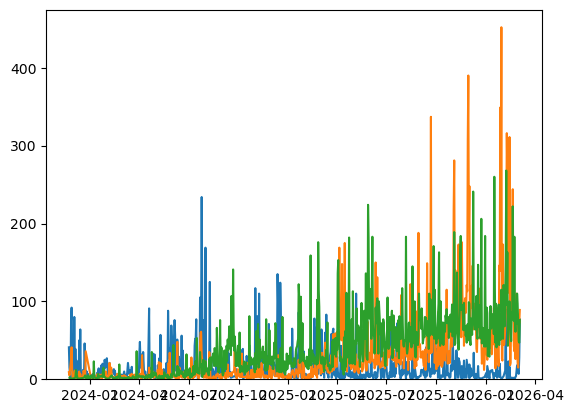

In [16]:
import matplotlib.pyplot as plt
data_filtered = {}

plt.figure()
for row in data.itertuples():
    print(row.label, row.data)
    xs = [point['x'] for point in row.data]
    ys = [point['y'] for point in row.data]
    print(len(xs), len(ys))
    # convert to datetime
    xs = [datetime.datetime.strptime(x, "%Y-%m-%d") for x in xs]
    plt.plot(xs, ys, label=row.label)
    data_filtered[row.label] = (xs, ys)

plt.ylim(bottom=0)

In [ ]:
# make a new dataframe with Day as the index and "logged in", "anonymous", "crawlers" as columns

new_df = pandas.DataFrame()

{'Logged in users': ([datetime.datetime(2023, 11, 23, 0, 0),
   datetime.datetime(2023, 11, 24, 0, 0),
   datetime.datetime(2023, 11, 26, 0, 0),
   datetime.datetime(2023, 11, 27, 0, 0),
   datetime.datetime(2023, 11, 28, 0, 0),
   datetime.datetime(2023, 11, 29, 0, 0),
   datetime.datetime(2023, 11, 30, 0, 0),
   datetime.datetime(2023, 12, 1, 0, 0),
   datetime.datetime(2023, 12, 2, 0, 0),
   datetime.datetime(2023, 12, 3, 0, 0),
   datetime.datetime(2023, 12, 4, 0, 0),
   datetime.datetime(2023, 12, 5, 0, 0),
   datetime.datetime(2023, 12, 6, 0, 0),
   datetime.datetime(2023, 12, 7, 0, 0),
   datetime.datetime(2023, 12, 8, 0, 0),
   datetime.datetime(2023, 12, 9, 0, 0),
   datetime.datetime(2023, 12, 10, 0, 0),
   datetime.datetime(2023, 12, 11, 0, 0),
   datetime.datetime(2023, 12, 12, 0, 0),
   datetime.datetime(2023, 12, 13, 0, 0),
   datetime.datetime(2023, 12, 14, 0, 0),
   datetime.datetime(2023, 12, 15, 0, 0),
   datetime.datetime(2023, 12, 16, 0, 0),
   datetime.datetime(202

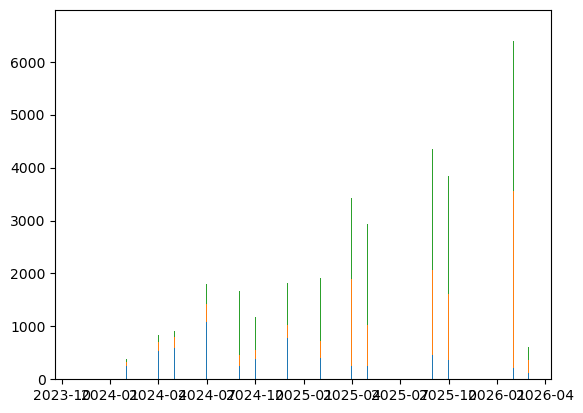

In [17]:
# group data per month
previous_ys = None
for label in data_filtered:
    xs, ys = data_filtered[label]
    # group by month
    data_per_month = {}
    for x, y in zip(xs, ys):
        month = x.strftime("%Y-%m")
        if month not in data_per_month:
            data_per_month[month] = 0
        data_per_month[month] += y
    # convert to lists
    xs = list(data_per_month.keys())
    ys = list(data_per_month.values())
    # convert to datetime
    xs = [datetime.datetime.strptime(x, "%Y-%m") for x in xs]
    plt.bar(xs, ys, label=label, bottom=previous_ys)

    if not previous_ys:
        previous_ys = ys.copy()
    else:
        previous_ys = [previous_ys[i] + ys[i] for i in range(len(ys))]
data_filtered